<a href="https://colab.research.google.com/github/EmberIpek/Machine-Learning/blob/main/LeNet_MLPNet_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab 2: Train different neural networks on MNIST dataset and implement convolution operation using python.

---

## Goal

*Goals:* The goals set up in our second lab are listed as follows:
1. we are going to implement a neural network based on multi-layer perceptrons for a given dataset, and we will observe the overfitting issue;
2. we are going to implement a convolutional neural network for a given dataset, and we will observe the effects on training brought by the large number of weights;
3. Make comparison between MLP and CNN;
4. Implement convolution operation by hand, which will be the basis for its optimization on hardware.

To achieve these goals, there are 3 Tasks and small questions attached to each task.

* Task 1: Train MLP on MNIST dataset and observe the overfitting issue.
* Task 2: Train and test CNN on MNIST datase.
* Task 3: Implement Convolution Operation in Python from scratch.

---

## Action before experiments

Before doing our tasks, please use File -> Save a copy to drive. Then, you can find Lab2 in "Colab Notebooks" in the root of your Google Drive.

---

## Submit to Blackboard

**[Recommend]**
* Click File -> Rename, then rename the notebook using "*lab2_firstname_G-Number*", like "*lab2_weiwen_GXXXX*". (Please save a copy to your own google drive before doing this!)
* Click File -> Print -> **Paper Size to A0** -> "Save as pdf"
* Login to [Blackboard](https://mymasonportal.gmu.edu/) -> Courses -> Enter "202270.83397 ECE-554-001 (Fall 2022)" ->  Labs -> Lab2
* Upload the saved pdf file and submit.

**[Alternative]**
* If your computer does not allow you to save the page as pdf. Please Download *.ipynb
* Upload to Blackboard (the same as the recommend approach).



---

## *Task 1:* Train MLP on MNIST dataset and observe the overfitting issue.

[MNIST dataset](http://yann.lecun.com/exdb/mnist/) is a large database of handwritten digits that is commonly used for training various image processing algorithms. When MNIST was first introduced in 1998, it took several weeks to train a CNN on the state-of-the-art workstation at that time. But now, we can train it efficiently with the help of GPU, and MNIST becomes a good dataset for us to learn how to train an MLP or a CNN for studying purpose.

In this task, we are going to build an MLP model for MNIST dataset. Before going to the implementation of MLP, let's first load the image from MNIST, and conduct pre-processing on the data.

To ease the procedure, we should ultilize a library, i.e., Torchvision. [Torchvision](https://medium.com/swlh/understanding-torchvision-functionalities-for-pytorch-391273299dc9) is a library for Computer Vision that goes hand in hand with PyTorch. It has utilities for efficient Image and Video transformations, some commonly used pre-trained models, and some standard datasets ( torchvision does not come bundled with PyTorch, you will have to install it separately. )



---
**[Question 1]: Try the following codes. Answer the question: In test_loader and train_loader, which one/ones need/needs to load data in a random way? And why? (5 points)**

**[Hint 1]: This is related to the SGD training optimization.**

**[Answer 1]:** The training data should be random because SGD samples a subset of the data at every iteration. This ensures that the model is learning and not just memorizing the dataset.

In [ ]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt


def load_data(data_root, batch_size=32, trainset_size=0):

  # Load training dataset from MNIST
  train_set = datasets.MNIST(data_root, train=True, download=True,
                            transform=transforms.ToTensor())
  # We randomly split the training dataset if a specified trainset_size is given.
  if trainset_size!=0:
    train_set, other_set = torch.utils.data.random_split(train_set, [trainset_size, len(train_set)-trainset_size])

  # Load testing dataset from MNIST
  test_set = datasets.MNIST(data_root, train=False, download=True,
                            transform=transforms.ToTensor())

  # Create data loader to load images from 2 datasets
  train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, pin_memory=True)
  test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False, pin_memory=True)

  print("Number of images in train dataset:",len(train_set))
  print("Number of images in test dataset:",len(test_set))

  return train_loader,test_loader

Number of images in train dataset: 1000
Number of images in test dataset: 10000
----------------------------------------------------------------------------------------------------
Images read from train_loader


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


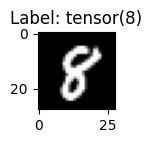

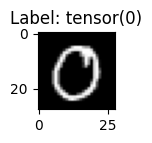

----------------------------------------------------------------------------------------------------
Images read from test_loader


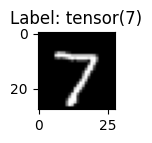

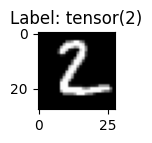

In [ ]:
import matplotlib.pyplot as plt

batch_size = 2

def plot_image_in_first_batch(data_loader, batch_size):
  for batch_idx, (inputs, targets) in enumerate(data_loader):
    for b in range(batch_size):
      pltsize=1
      plt.figure(figsize=(10*pltsize, pltsize))
      plt.imshow(inputs[b].reshape(28,28), cmap="gray")
      plt.title('Label: '+str(targets[b]))
      plt.show()
    break


train_loader,test_loader = load_data(data_root="./", batch_size=batch_size, trainset_size=1000)

# Visualization of a batch of images in 2 datasets
print("-"*100)
print("Images read from train_loader")
plot_image_in_first_batch(train_loader, batch_size=batch_size)
print("-"*100)
print("Images read from test_loader")
plot_image_in_first_batch(test_loader, batch_size=batch_size)


---
Now, we are ready to build the MLP network, train it, and test it.

Before we build the network, we are given the standard training functions and inferencing functions.

These functions will take the follwoing input parameters:
* data_loader: the data loader created by the *load_data* function
* model: the machine learning model to use
* criterion: the cost function, like cross_entropy introduced in Lec 2
* optimizer (only training): the optimizer, like SGD
* epoch (only training): the total epochs for training
* device: cpu (default) or gpu

In [ ]:
def train(data_loader, model, criterion, optimizer, epoch, device='cpu'):
    all_losses = []
    correct = 0
    print_freq = int(len(data_loader)/20)+1
    for batch_idx, (inputs, targets) in enumerate(data_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        # Trace loss and accuracy & Print log information
        all_losses.append(loss)
        pred = outputs.data.max(1, keepdim=True)[1]
        correct += pred.eq(targets.data.view_as(pred)).cpu().sum()
        if batch_idx % print_freq == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(inputs), len(data_loader.dataset),
                100. * batch_idx / len(data_loader), loss.data.item()))

    train_acc = 100. * correct / len(data_loader.dataset)
    train_loss = float(sum(all_losses))/len(data_loader.dataset)
    print("Train set: Average loss: {:.4f}, Accuracy {}/{} ({:.2f}%)".format(
        train_loss, correct, len(data_loader.dataset), train_acc))
    return train_loss, train_acc


def inference(data_loader, model, criterion, device='cpu'):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(data_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss

            pred = outputs.data.max(1, keepdim=True)[1]  # get the index of the class with the maximum log-probability
            correct += pred.eq(targets.data.view_as(pred)).cpu().sum()
    test_acc = 100. * correct / len(data_loader.dataset)
    test_loss /= len(data_loader.dataset)
    print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)'.format(
        test_loss, correct, len(data_loader.dataset),test_acc))
    return test_loss,test_acc

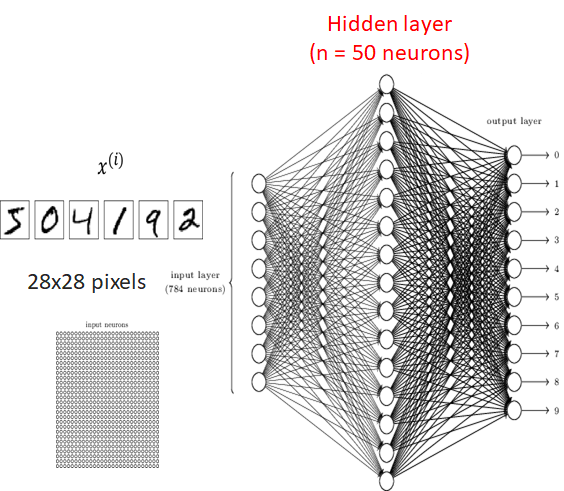

---
Based on the above defined functions, we are now able to define our neural network, train it and test it on MNIST dataset

**[Question 2]: Please fill in missing codes in the MLPNet, where the MLPNet has the following paramters and settings. (5 points)**

1. The hidden layer has the **ReLU** non-linear function.
2. In **forward**, the 28 * 28 MNIST image needs to be flattened by using "x = input.view(-1, 28 * 28)" first.
3. The output dimension of the hidden layer is: 50
4. The output dimension of the output layer is: 10

**[Answer 2]:** (Please fill the below code cell)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MLPNet(nn.Module):
    def __init__(self):
      super(MLPNet, self).__init__()
      # hidden layer: 784 inputs, 50 outputs
      self.hidden_layer = nn.Linear(784, 50)
      self.relu = nn.ReLU()
      # output layer: 50 inputs, 10 outputs
      self.output_layer = nn.Linear(50, 10)

    def forward(self, x):
      x = x.view(-1, 28 * 28)
      x = self.hidden_layer(x)
      x = self.relu(x)
      x = self.output_layer(x)

      return x

**[Question 3]: Calculate the number of parameters in the MLPNet by hand. Use the following codes to check the correctness of your answer. (5 points)**  

**[Answer 3]:** hidden layer: 28 * 28 * 50 weights + 50 biases = 39200  
output layer: 50 * 10 weights + 10 biases = 510  
total: 39760

In [ ]:
import numpy as np
# Setting Experimental Parameters
net = MLPNet()

model_parameters = filter(lambda p: p.requires_grad, net.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print(params)

39760


**[Question 4]: Design the experiment to show the overfitting issue caused by the lack of training data. (20 points)**

Before carrying out the comparison, we first fix some training hyperparameters in all the experiements in this lab and we are going to create an *execution()* function to simplify the codes.

Here, we will fix the following training hyperparameters:
* lr = 0.01  # learning rate
* batch_size = 32 # batch size for training
* We use the [CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) as the cost function, which contains the softmax to make the output as probability.
* We use the [SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) optimizer

There are 3 hyperparamters needed to be deteremined by different experiements, including:
1. The neural network (net)
2. The total epochs for training (epochs)
3. The number of training images to be used (trainset_size)

In the exeuction function, we will follow 5 steps to train the network.
1. Use the pre-defined *load_data()* function to create the training and testing data loader
2. Train the model using the pre-defined *train()* function.
3. Test the trained model using the pre-defined *inference()* function.
4. Keep the train_loss, train_acc, test_loss, and test_acc as python lists.
5. Go back to step 2 until we reach the pre-defined maximum epochs.


In [ ]:
def execution(net, epochs, trainset_size):

  print("-"*20,"model properties","-"*20)
  model_parameters = filter(lambda p: p.requires_grad, net.parameters())
  params = sum([np.prod(p.size()) for p in model_parameters])
  print("Number of parameters: {}".format(params))

  lr = 0.01
  batch_size=32
  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(net.parameters(), lr=lr)

  print("="*100)
  print("-"*20,"dataset properites","-"*20)
  train_loader,test_loader = load_data(data_root="./", batch_size=batch_size, trainset_size=trainset_size)

  print("="*100)
  print("-"*20,"network training begin","-"*20)

  train_loss, train_acc = [], []
  test_loss, test_acc = [], []
  for epoch in range(0, epochs):
      tr_loss,tr_acc = train(train_loader, net, criterion, optimizer, epoch)
      te_loss,te_acc = inference(test_loader, net, criterion)

      train_loss.append(tr_loss)
      train_acc.append(tr_acc)
      test_loss.append(te_loss)
      test_acc.append(te_acc)

  print("="*100)
  print("-"*20,"plotting loss and accuracy","-"*20)
  # plot the trace of accuracy or loss
  plt.figure(figsize=(5,3))
  plt.plot(range(1,epochs+1), train_acc)
  plt.plot(range(1,epochs+1), test_acc)
  plt.title('Train Accuracy using {} training data in {} epochs'.format(trainset_size,epochs))

  plt.figure(figsize=(5,3))
  plt.plot(range(1,epochs+1), train_loss)
  plt.plot(range(1,epochs+1), test_loss)
  plt.title('Train Loss using {} training data in {} epochs'.format(trainset_size,epochs))

  print("="*100)

  return train_loss,train_acc,test_loss,test_acc

**Now, it's time to train the MLPNet for 100 epochs with 1,000 images, and observe its performance. You need to implement the network and use the *execution()* function to train the network.**

Here we use **%%time** to get the elapsed time for our training process.

-------------------- model properties --------------------
Number of parameters: 39760
-------------------- dataset properites --------------------
Number of images in train dataset: 1000
Number of images in test dataset: 10000
-------------------- network training begin --------------------
Train Epoch: 0 [0/1000 (0%)]	Loss: 2.314446
Train Epoch: 0 [64/1000 (6%)]	Loss: 2.320294
Train Epoch: 0 [128/1000 (12%)]	Loss: 2.304177
Train Epoch: 0 [192/1000 (19%)]	Loss: 2.304571
Train Epoch: 0 [256/1000 (25%)]	Loss: 2.291863
Train Epoch: 0 [320/1000 (31%)]	Loss: 2.290992
Train Epoch: 0 [384/1000 (38%)]	Loss: 2.304906
Train Epoch: 0 [448/1000 (44%)]	Loss: 2.278270
Train Epoch: 0 [512/1000 (50%)]	Loss: 2.289720
Train Epoch: 0 [576/1000 (56%)]	Loss: 2.273805
Train Epoch: 0 [640/1000 (62%)]	Loss: 2.264221
Train Epoch: 0 [704/1000 (69%)]	Loss: 2.267957
Train Epoch: 0 [768/1000 (75%)]	Loss: 2.249227
Train Epoch: 0 [832/1000 (81%)]	Loss: 2.262450
Train Epoch: 0 [896/1000 (88%)]	Loss: 2.278656
Train E

/tmp/ipython-input-1667619111.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  train_loss = float(sum(all_losses))/len(data_loader.dataset)


Test set: Average loss: 0.0705, Accuracy: 2446/10000 (24.46%)
Train Epoch: 1 [0/1000 (0%)]	Loss: 2.211814
Train Epoch: 1 [64/1000 (6%)]	Loss: 2.229284
Train Epoch: 1 [128/1000 (12%)]	Loss: 2.231610
Train Epoch: 1 [192/1000 (19%)]	Loss: 2.253752
Train Epoch: 1 [256/1000 (25%)]	Loss: 2.217215
Train Epoch: 1 [320/1000 (31%)]	Loss: 2.249363
Train Epoch: 1 [384/1000 (38%)]	Loss: 2.218652
Train Epoch: 1 [448/1000 (44%)]	Loss: 2.214186
Train Epoch: 1 [512/1000 (50%)]	Loss: 2.185863
Train Epoch: 1 [576/1000 (56%)]	Loss: 2.204548
Train Epoch: 1 [640/1000 (62%)]	Loss: 2.239221
Train Epoch: 1 [704/1000 (69%)]	Loss: 2.192612
Train Epoch: 1 [768/1000 (75%)]	Loss: 2.234376
Train Epoch: 1 [832/1000 (81%)]	Loss: 2.184107
Train Epoch: 1 [896/1000 (88%)]	Loss: 2.165633
Train Epoch: 1 [960/1000 (94%)]	Loss: 2.153907
Train set: Average loss: 0.0708, Accuracy 317/1000 (31.70%)
Test set: Average loss: 0.0685, Accuracy: 3337/10000 (33.37%)
Train Epoch: 2 [0/1000 (0%)]	Loss: 2.153087
Train Epoch: 2 [64/1000 (

([0.07301366424560547,
  0.07079502868652343,
  0.06842714691162109,
  0.06571662139892578,
  0.06311135864257812,
  0.060080810546875,
  0.057656711578369144,
  0.05453336715698242,
  0.051584087371826175,
  0.04859971618652344,
  0.045854736328125,
  0.042916114807128904,
  0.040384780883789065,
  0.037628299713134764,
  0.03542550659179688,
  0.03325533676147461,
  0.031190929412841798,
  0.029603614807128906,
  0.02800184440612793,
  0.02653245735168457,
  0.02563484764099121,
  0.02401729965209961,
  0.023262763977050783,
  0.022645376205444337,
  0.021595928192138673,
  0.020751649856567383,
  0.020230512619018554,
  0.01974040985107422,
  0.019180940628051757,
  0.01829771423339844,
  0.018167507171630858,
  0.017769102096557618,
  0.01706469917297363,
  0.016491542816162108,
  0.0164611873626709,
  0.016561717987060548,
  0.01577125358581543,
  0.015760153770446778,
  0.014760255813598633,
  0.014497893333435059,
  0.014217236518859862,
  0.014171099662780762,
  0.0137650470733

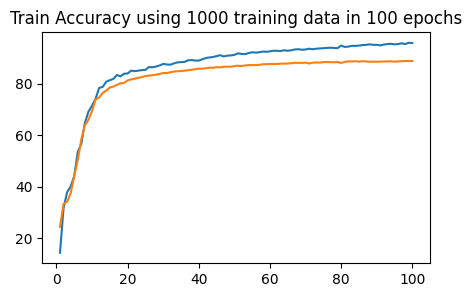

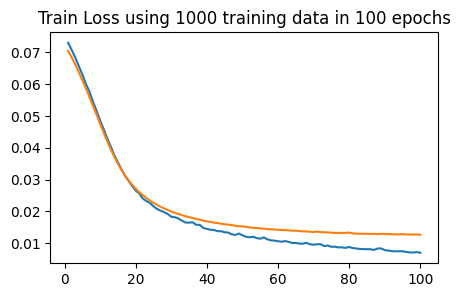

In [ ]:
%%time
# Run the training and testing process in the following lines.
# YOU NEED TO FILL THIS CODE CELL
execution(net, 100, 1000)

**Next, let's train the MLPNet for 10 epochs with 50,000 images, and observe its performance. You need to implement the network again and use the *execution()* function to train the network.****

-------------------- model properties --------------------
Number of parameters: 39760
-------------------- dataset properites --------------------
Number of images in train dataset: 50000
Number of images in test dataset: 10000
-------------------- network training begin --------------------
Train Epoch: 0 [0/50000 (0%)]	Loss: 0.346346
Train Epoch: 0 [2528/50000 (5%)]	Loss: 0.390771
Train Epoch: 0 [5056/50000 (10%)]	Loss: 0.508637
Train Epoch: 0 [7584/50000 (15%)]	Loss: 0.494411
Train Epoch: 0 [10112/50000 (20%)]	Loss: 0.305284
Train Epoch: 0 [12640/50000 (25%)]	Loss: 0.298842
Train Epoch: 0 [15168/50000 (30%)]	Loss: 0.311710
Train Epoch: 0 [17696/50000 (35%)]	Loss: 0.296830
Train Epoch: 0 [20224/50000 (40%)]	Loss: 0.113162
Train Epoch: 0 [22752/50000 (45%)]	Loss: 0.397617
Train Epoch: 0 [25280/50000 (51%)]	Loss: 0.386842
Train Epoch: 0 [27808/50000 (56%)]	Loss: 0.349467
Train Epoch: 0 [30336/50000 (61%)]	Loss: 0.102140
Train Epoch: 0 [32864/50000 (66%)]	Loss: 0.131872
Train Epoch: 0 

([0.011563568115234376,
  0.010093779296875,
  0.009267879028320313,
  0.008666240234375,
  0.008156039428710937,
  0.007711438598632813,
  0.00731641845703125,
  0.006959732666015625,
  0.006636905517578125,
  0.006343297119140625],
 [tensor(89.4960),
  tensor(90.8100),
  tensor(91.5180),
  tensor(92.1580),
  tensor(92.5920),
  tensor(93.0300),
  tensor(93.3780),
  tensor(93.6960),
  tensor(94.0680),
  tensor(94.2660)],
 [tensor(0.0103),
  tensor(0.0094),
  tensor(0.0088),
  tensor(0.0083),
  tensor(0.0078),
  tensor(0.0074),
  tensor(0.0071),
  tensor(0.0068),
  tensor(0.0065),
  tensor(0.0063)],
 [tensor(91.0900),
  tensor(91.4900),
  tensor(92.0300),
  tensor(92.6200),
  tensor(93.0100),
  tensor(93.2500),
  tensor(93.4800),
  tensor(93.8900),
  tensor(93.9900),
  tensor(94.2700)])

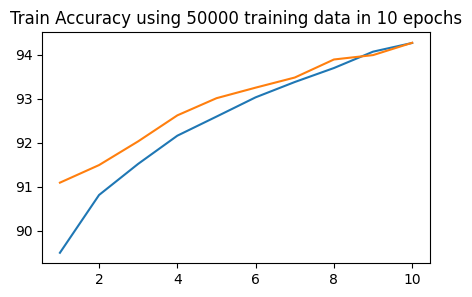

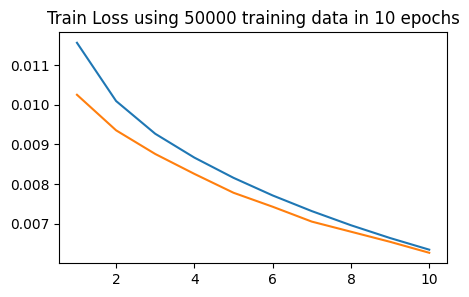

In [ ]:
%%time
# Run the training and testing process in the following lines.
# YOU NEED TO FILL THIS CODE CELL
execution(net, 10, 50000)

---
Now, you have already seen that the overfitting exists if the training data is much smaller than the number of parameters in the network.

**[Answer 4]:** Please first complete the above program and execute it. Then, you need to fill up the following table. The value to be filled here is the training accuracy and test accuracy at the last epoch.

|                |Training Accuracy|Test Accuracy |    Gap   |
| :------------- | :-------------: |:-----------: |:-------: |
| 1000 @ 100epoch|     95.90%      |    88.64%    |   7.26   |
| 50000 @ 10epoch|     94.29%      |    94.53%    |   0.24   |


---
## Task 2: Train and test CNN on MNIST datase.


Now, we are going to see the difference between MLP and CNN.

**[Qustion 5]: Implemente convolution neural network for MNIST dataset (LeNet) and compare it with the equalevent MLP. (30 points)**

**[Answer 5]:** (Please complete the following codes for LeNet and DeepMLPNet . Then, complete the comaprison following the instructions)

**Grade details:**
* LeNet Implementation (10 points)
* DeepMLPNet (10 points)
* Comparison (10 points)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class LeNet(nn.Module):
    def __init__(self):
      super(LeNet, self).__init__()
      # layer1 convolution: 6 channels 24*24
      self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, bias=False)
      # layer2 subsampling: 6 12*12 channels
      self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
      # layer3 convolution: 16 10*10 channels
      self.conv3 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1, bias=False)
      # layer4 subsampling: 16 5*5 channels
      self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
      # layer5: 400 inputs, 120 outputs
      #self.conv5 = nn.conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1, bias=False)
      self.layer5 = nn.Linear(400, 120)
      # layer6: 120 inputs, 84 outputs
      self.layer6 = nn.Linear(120, 84)
      # layer7: 84 inputs, 10 outputs
      self.layer7 = nn.Linear(84, 10)

    def forward(self, x):
      x = self.conv1(x)
      x = self.pool2(x)
      x = self.conv3(x)
      x = self.pool4(x)

      x = x.view(x.size(0), -1)
      x = self.layer5(x)
      x = self.layer6(x)
      x = self.layer7(x)

      return x

**Now, it's time to train the LeNet for 10 epochs with 50,000 images, and observe its performance. You need to implement the network and use the *execution()* function to train the network.**

-------------------- model properties --------------------
Number of parameters: 60148
-------------------- dataset properites --------------------
Number of images in train dataset: 50000
Number of images in test dataset: 10000
-------------------- network training begin --------------------
Train Epoch: 0 [0/50000 (0%)]	Loss: 2.329784
Train Epoch: 0 [2528/50000 (5%)]	Loss: 2.293886
Train Epoch: 0 [5056/50000 (10%)]	Loss: 2.268446
Train Epoch: 0 [7584/50000 (15%)]	Loss: 2.227913
Train Epoch: 0 [10112/50000 (20%)]	Loss: 2.058803
Train Epoch: 0 [12640/50000 (25%)]	Loss: 1.624867
Train Epoch: 0 [15168/50000 (30%)]	Loss: 0.968063
Train Epoch: 0 [17696/50000 (35%)]	Loss: 0.579596
Train Epoch: 0 [20224/50000 (40%)]	Loss: 0.502621
Train Epoch: 0 [22752/50000 (45%)]	Loss: 0.678208
Train Epoch: 0 [25280/50000 (51%)]	Loss: 0.559895
Train Epoch: 0 [27808/50000 (56%)]	Loss: 0.428058
Train Epoch: 0 [30336/50000 (61%)]	Loss: 0.422592
Train Epoch: 0 [32864/50000 (66%)]	Loss: 0.335603
Train Epoch: 0 

([0.0286884228515625,
  0.007719088745117187,
  0.004961429138183594,
  0.0037943743896484373,
  0.0032259954833984373,
  0.0028463543701171875,
  0.0025754278564453126,
  0.002375211486816406,
  0.002212016143798828,
  0.0020902325439453124],
 [tensor(71.7040),
  tensor(92.7580),
  tensor(95.2720),
  tensor(96.3540),
  tensor(96.8660),
  tensor(97.2460),
  tensor(97.4760),
  tensor(97.7280),
  tensor(97.8600),
  tensor(98.0100)],
 [tensor(0.0104),
  tensor(0.0066),
  tensor(0.0039),
  tensor(0.0038),
  tensor(0.0029),
  tensor(0.0024),
  tensor(0.0022),
  tensor(0.0027),
  tensor(0.0023),
  tensor(0.0019)],
 [tensor(90.3300),
  tensor(93.5400),
  tensor(96.2500),
  tensor(96.3500),
  tensor(96.9700),
  tensor(97.5700),
  tensor(97.7500),
  tensor(97.2400),
  tensor(97.7200),
  tensor(98.1000)])

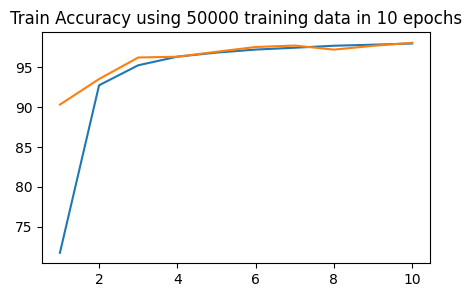

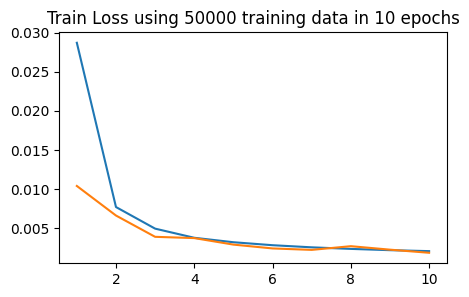

In [ ]:
%%time
# Run the training and testing codes in the following lines.
# YOU NEED TO FILL THIS CODE CELL
net = LeNet()
execution(net, 10, 50000)

**Now, let's design the *DeepMLPNet*, which has the same number of neurons as the above CNN network.**

For the first hidden layer, the input is the MNIST image, which is 28 * 28 * 1, the output will be 24 * 24 * 6. The number of output neuron is deteremined by the first convolution operation of LeNet, where we apply the kernels with size of 5, and the number of output channels is set to 6.

After this, a pooling operation is performed, which creates a new layer, having 12 * 12 * 6 output neurons.

Similarily, you can calculate the number of output neurons of the third hidden layer of DeepMLPNet, which corresponds to the second convolution operation, and the fourth hidden layer of DeepMLPNet, which corresponds to the second pooling operation.

Lastly, we will apply the same fully connected layers as the ones in LeNet to build layer 5-7 in DeepMLPNet.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DeepMLPNet(nn.Module):
    def __init__(self):
        super(DeepMLPNet, self).__init__()
        # For the first hidden layer, the input is the MNIST image, which is 28 * 28 * 1, the output will be 24 * 24 * 6.
        self.layer1 = nn.Linear(784, 3456)
        # The number of output neuron is deteremined by the first convolution operation of LeNet,
        # where we apply the kernels with size of 5, and the number of output channels is set to 6.
        # After this, a pooling operation is performed, which creates a new layer, having 12 * 12 * 6 output neurons.
        self.layer2 = nn.Linear(3456, 864)
        # Similarily, you can calculate the number of output neurons of the third hidden layer of DeepMLPNet, which corresponds to the second convolution operation
        self.layer3 = nn.Linear(864, 1600)
        # and the fourth hidden layer of DeepMLPNet, which corresponds to the second pooling operation.
        self.layer4 = nn.Linear(1600, 400)
        # layer5: 400 inputs, 120 outputs
        self.layer5 = nn.Linear(400, 120)
        # layer6: 120 inputs, 84 outputs
        self.layer6 = nn.Linear(120, 84)
        # layer7: 84 inputs, 10 outputs
        self.layer7 = nn.Linear(84, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.layer6(x)
        x = self.layer7(x)

        return x

**In the following code cells, you need to train *LeNet* and *DeepMLPNet* for 1 epoch using 50,000 training data to capture their execution time for comparison.**

-------------------- model properties --------------------
Number of parameters: 60148
-------------------- dataset properites --------------------
Number of images in train dataset: 50000
Number of images in test dataset: 10000
-------------------- network training begin --------------------
Train Epoch: 0 [0/50000 (0%)]	Loss: 2.303022
Train Epoch: 0 [2528/50000 (5%)]	Loss: 2.281623
Train Epoch: 0 [5056/50000 (10%)]	Loss: 2.248934
Train Epoch: 0 [7584/50000 (15%)]	Loss: 2.240561
Train Epoch: 0 [10112/50000 (20%)]	Loss: 2.182904
Train Epoch: 0 [12640/50000 (25%)]	Loss: 1.972832
Train Epoch: 0 [15168/50000 (30%)]	Loss: 1.469996
Train Epoch: 0 [17696/50000 (35%)]	Loss: 0.807598
Train Epoch: 0 [20224/50000 (40%)]	Loss: 0.729288
Train Epoch: 0 [22752/50000 (45%)]	Loss: 0.670402
Train Epoch: 0 [25280/50000 (51%)]	Loss: 0.360797
Train Epoch: 0 [27808/50000 (56%)]	Loss: 0.660236
Train Epoch: 0 [30336/50000 (61%)]	Loss: 0.941871
Train Epoch: 0 [32864/50000 (66%)]	Loss: 0.424325
Train Epoch: 0 

([0.030670400390625], [tensor(71.2200)], [tensor(0.0096)], [tensor(90.7900)])

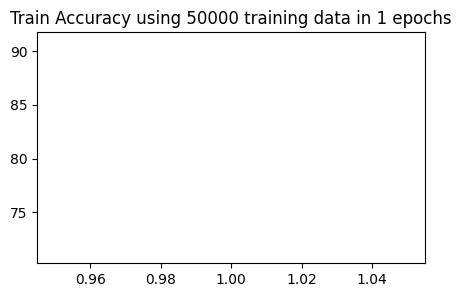

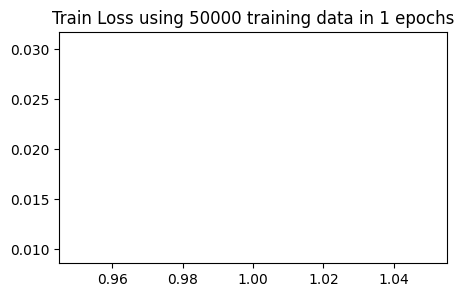

In [ ]:
%%time
#LeNet
# YOU NEED TO FILL THIS CODE CELL
net = LeNet()
execution(net, 1, 50000)

-------------------- model properties --------------------
Number of parameters: 7783342
-------------------- dataset properites --------------------
Number of images in train dataset: 50000
Number of images in test dataset: 10000
-------------------- network training begin --------------------
Train Epoch: 0 [0/50000 (0%)]	Loss: 2.314481
Train Epoch: 0 [2528/50000 (5%)]	Loss: 2.278549
Train Epoch: 0 [5056/50000 (10%)]	Loss: 2.274263
Train Epoch: 0 [7584/50000 (15%)]	Loss: 2.257551
Train Epoch: 0 [10112/50000 (20%)]	Loss: 2.236402
Train Epoch: 0 [12640/50000 (25%)]	Loss: 2.199238
Train Epoch: 0 [15168/50000 (30%)]	Loss: 2.048308
Train Epoch: 0 [17696/50000 (35%)]	Loss: 1.810880
Train Epoch: 0 [20224/50000 (40%)]	Loss: 1.627559
Train Epoch: 0 [22752/50000 (45%)]	Loss: 1.066079
Train Epoch: 0 [25280/50000 (51%)]	Loss: 0.878143
Train Epoch: 0 [27808/50000 (56%)]	Loss: 0.762228
Train Epoch: 0 [30336/50000 (61%)]	Loss: 0.682418
Train Epoch: 0 [32864/50000 (66%)]	Loss: 0.662392
Train Epoch: 

([0.03995935302734375], [tensor(61.2960)], [tensor(0.0158)], [tensor(84.8400)])

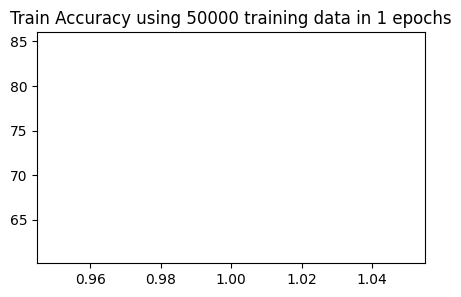

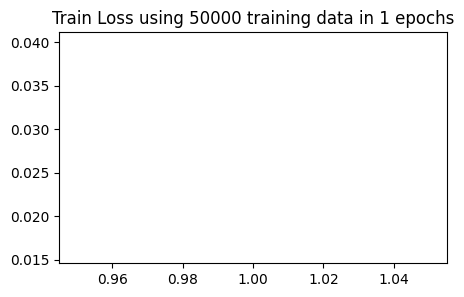

In [ ]:
%%time
#DeepMLPNet
# YOU NEED TO FILL THIS CODE CELL
net = DeepMLPNet()
execution(net, 1, 50000)

**Now, you need to fill in the following two tables to complete this task.**

Comparison between MLPNet in Task 1 and LeNet, training with 10 epochs and 50,000 training images

|                | # of parameters | Number of Layers|  Test Accuracy  |
| :------------- | :-------------: |:-----------:    |:-------: |
| MLPNet         |        39760        |       2          |     94.53%   |
| LeNet          |         60148      |         7        |    98.03%  |



Comparison between DeepMLPNet and LeNet, training with 1 epoch and 50,000 training images

|                | # of parameters | Wall Time       |
| :------------- | :-------------: |:-----------:    |
| DeepMLPNet     |          7783342       |         1min 37s        |
| LeNet          |        60148         |          22.7 s       |


---
## Task 3: Implement Convolution Operation in Python from scratch.

Although we can use *nn.Conv2d()* to build the convolutional neural network (CNN),when we try to optimize CNN on hardware, we need to be aware of the details of the implementation of the convolution operation.

**[Question 6]: In this task, you will need to implement the convolution operation by hand. (35 points)**

We have learned the detailed hyperparameters of the convolution operation in Lecture 3 (see the following cell).

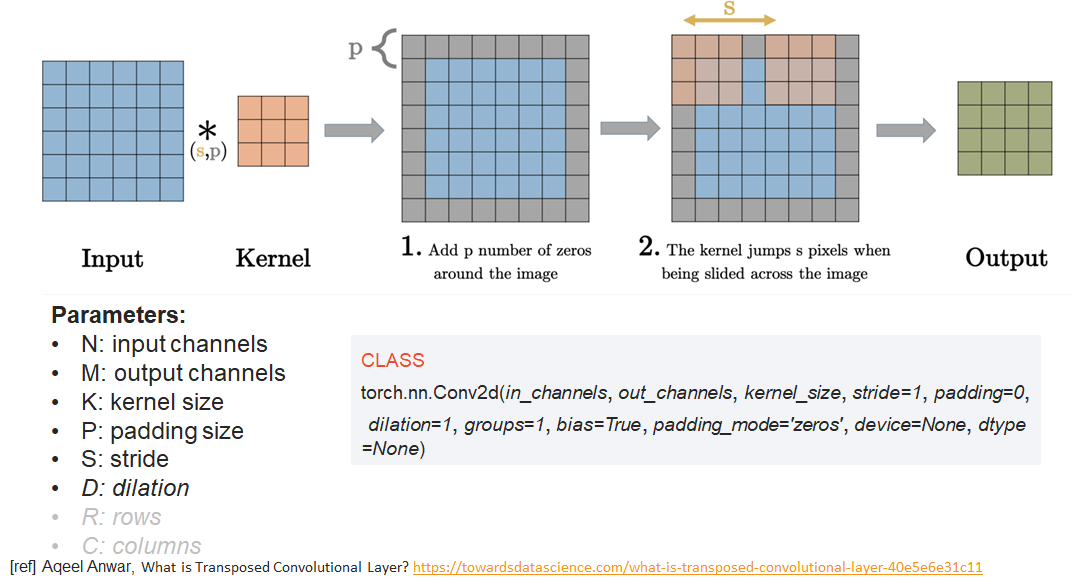

To simplify the implementation, you are required to implement a self-designed *ml4emb_conv2d* function with fixed padding size (P=0), fixed stride (S=1) and fixed dilaition (D=1).

In addition to the above parameters, *ml4emb_conv2d* function takes input feature maps (IFM), and kernels (W) as input, and it is expected to return the output feature maps (OFM).

From IFM and W, we can extract the parameters, including:
* (B) batch size from IFM.size()[0]
* (N) number of input channels from IFM.size()[1] & W.size()[1]
* (R) input rows from IFM.size()[2]
* (C) input columns from IFM.size()[3]
* (K) kernel size from W.size()[2] & W.size()[3]
* (M) number of output channels from W.size()[0]


We provie the function interface and you need to implement the convolution operation using *for* loops.

In [ ]:
import sys
def ml4emb_conv2d(IFM, W):

  if W.size()[1] != IFM.size()[1]:
    print("in channel not consistent")
    sys.exit(0)

  if W.size()[2] != W.size()[3]:
    print("kernel size not consistent")
    sys.exit(0)

  B = IFM.size()[0]
  N = IFM.size()[1]
  R = IFM.size()[2]
  C = IFM.size()[3]
  K = W.size()[2]
  M = W.size()[0]
  oR = R - K + 1
  oC = C - K + 1

  OFM = torch.zeros(B,M,oR,oC)

  # YOU NEED TO IMPLEMENT THE CONVOLUTION OPERATION HERE TO GET "OFM" FROM "IFM" AND "W"
  for batch_number in range(B):
    for output_channel in range(M):
      for input_channel in range(N):
        for output_row in range(oR):
          for output_column in range(oC):
            for kernel_row in range(K):
              for kernel_column in range(K):
                OFM[batch_number][output_channel][output_row][output_column] += IFM[batch_number][input_channel][output_row + kernel_row][output_column + kernel_column] * W[output_channel][input_channel][kernel_row][kernel_column]

  return OFM

In [ ]:
input = torch.tensor([[[[0,0,1,1,1,0],
                        [0,0,0,0,1,0],
                        [0,0,0,1,1,0],
                        [0,0,1,1,1,0],
                        [0,0,0,0,1,0],
                        [0,0,1,1,1,0]],

                       [[0,0,1,1,1,0],
                        [0,1,0,0,0,0],
                        [0,1,0,0,0,0],
                        [0,1,1,1,1,0],
                        [0,1,0,0,1,0],
                        [0,1,1,1,1,0]]]],dtype=torch.float)

weight = torch.tensor([[[[-1,0,1],
                         [-2,0,2],
                         [-1,0,1]],

                        [[-1,-2,-1],
                         [0,0,0],
                         [1,2,1]]],

                       [[[0,0,0],
                         [0,0,0],
                         [0,0,0]],
                        [[0,0,0],
                         [0,0,0],
                         [0,0,0]]],

                       [[[0,0,0],
                         [0,0,0],
                         [0,0,0]],
                        [[0,0,0],
                         [0,0,0],
                         [0,0,0]]],

                       [[[0,0,0],
                         [0,0,0],
                         [0,0,0]],
                        [[0,0,0],
                         [0,0,0],
                         [0,0,0]]],
                      ], dtype=torch.float)


print("="*20,"TEST CORRECTNESS","="*20)
print("-"*20,"our results","-"*20)
ofm = ml4emb_conv2d(input, weight)
print(ofm)
print("="*100)
print("-"*20,"pytorch results","-"*20)
conv = nn.Conv2d(in_channels=2, out_channels=4, kernel_size=3, stride=1, bias=False)
conv.weight = torch.nn.Parameter(weight)
o_conv = conv(input)
print(o_conv)
print("="*100)
difference = (ofm-o_conv).sum()
if difference == 0:
  print("correct")
else:
  print("inconsistent, need revision.")

==================== TEST CORRECTNESS ====================
-------------------- our results --------------------
tensor([[[[ 2.,  0., -1., -5.],
          [ 2.,  6.,  7.,  0.],
          [ 2.,  3.,  3., -1.],
          [ 2.,  2.,  2., -2.]],

         [[ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.]],

         [[ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.]],

         [[ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.]]]])
-------------------- pytorch results --------------------
tensor([[[[ 2.,  0., -1., -5.],
          [ 2.,  6.,  7.,  0.],
          [ 2.,  3.,  3., -1.],
          [ 2.,  2.,  2., -2.]],

         [[ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.]],

         [[ 0.,  0.,  0.,  0.],
          [ 0., 